In [2]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np

In [3]:
from archs.cnn1 import CNN1
import pickle 
import torch 
from torch import nn
from environment import CoronagraphEnvironment
import numpy as np

In [4]:
# properties of coronagraph:

NUM_MODES = 25
PIXEL_RESOLUTION = 256
OVERSIZNG_FACTOR = 1
NUM_AIRY=7
CORONAGRAPH_CHARGE = 6
PIXELS_PER_SPACIAL_RES = 4

In [5]:
with open(f"data/V4 gen 10000.pkl", 'rb') as f:
    data = pickle.load(f)

difference (should be 0): [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 4.13590306e-25 4.13590306e-25
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


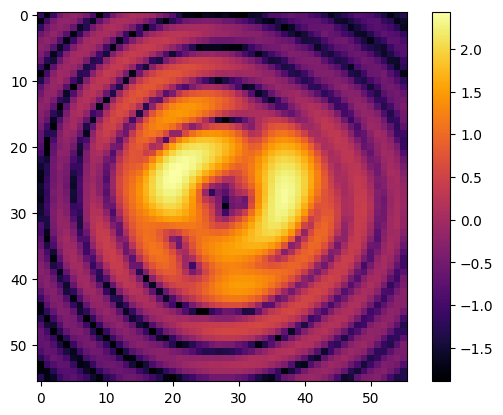

In [6]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

X = np.array(data['images'])
y = np.array(data['dm_settings'])

unnormalized_y0 = y[0]

# normalize y
y_mean = np.mean(y)
y_std_dev = np.std(y)
y = (y - y_mean) / y_std_dev

renormalized_y0 = y[0] * y_std_dev + y_mean 
print(f"difference (should be 0): {unnormalized_y0 - renormalized_y0}")

# normalize x
# X = np.cbrt(X)
X = np.log10(X + 1)
X_mean, X_std = np.mean(X), np.std(X)
X -= X_mean
X /= X_std
plt.imshow(X[10][0], cmap='inferno')
plt.colorbar()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
model = CNN1(final_output_dim=y_train.shape[1], image_input_shape=X_train.shape[1:], dm_input_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_train_tensor = torch.tensor(X_train, dtype=torch.float)
y_train_tensor = torch.tensor(y_train, dtype=torch.float)


In [9]:
y_test_tensor = torch.tensor(y_test, dtype=torch.float)
X_test_tensor = torch.tensor(X_test, dtype=torch.float)
img1_train = X_train_tensor[:, 0, :, :].unsqueeze(1)
img2_train = X_train_tensor[:, 1, :, :].unsqueeze(1)

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

img1_train = img1_train.to(device)
img2_train = img2_train.to(device)
list_placeholder = torch.zeros(size=(4000,1)).to(device)
y_train_tensor = y_train_tensor.to(device)
model = model.to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).to(device)

img1_test = X_test_tensor[:, 0, :, :].unsqueeze(1).to(device)
img2_test = X_test_tensor[:, 1, :, :].unsqueeze(1).to(device)

In [ ]:
# ...existing code...
epochs = 5000
batch_size = 64  # lower if you still get OOM
from torch.utils.data import TensorDataset, DataLoader

# create placeholders that match actual dataset sizes
list_placeholder_train = torch.zeros(len(img1_train), 1)
list_placeholder_val = torch.zeros(len(img1_test), 1)

# Build CPU datasets and dataloaders (use num_workers=0 in Jupyter/Windows)
train_dataset = TensorDataset(
    img1_train.cpu(),            # (N_train,1,H,W)
    img2_train.cpu(),            # (N_train,1,H,W)
    list_placeholder_train.cpu(),# (N_train,1)
    y_train_tensor.cpu()         # (N_train, n_dm)
)
val_dataset = TensorDataset(
    img1_test.cpu(),             # (N_val,1,H,W)
    img2_test.cpu(),             # (N_val,1,H,W)
    list_placeholder_val.cpu(),  # (N_val,1)
    y_test_tensor.cpu()          # (N_val, n_dm)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# AMP setup (optional)
scaler = None
use_amp = torch.cuda.is_available()
if use_amp:
    from torch.cuda.amp import GradScaler, autocast
    scaler = GradScaler()

# training loop (unchanged)
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for b_img1, b_img2, b_pl, b_y in train_loader:
        b_img1 = b_img1.to(device, non_blocking=True)
        b_img2 = b_img2.to(device, non_blocking=True)
        b_pl = b_pl.to(device, non_blocking=True)
        b_y = b_y.to(device, non_blocking=True)

        optimizer.zero_grad()
        if use_amp:
            with autocast():
                outputs = model(b_img1, b_img2, b_pl)
                loss = criterion(outputs, b_y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(b_img1, b_img2, b_pl)
            loss = criterion(outputs, b_y)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * b_img1.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for v_img1, v_img2, v_pl, v_y in val_loader:
            v_img1 = v_img1.to(device, non_blocking=True)
            v_img2 = v_img2.to(device, non_blocking=True)
            v_pl = v_pl.to(device, non_blocking=True)
            v_y = v_y.to(device, non_blocking=True)
            if use_amp:
                with autocast():
                    v_out = model(v_img1, v_img2, v_pl)
                    v_loss = criterion(v_out, v_y)
            else:
                v_out = model(v_img1, v_img2, v_pl)
                v_loss = criterion(v_out, v_y)
            val_running += v_loss.item() * v_img1.size(0)

    val_loss = val_running / len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
# ...existing code...

AssertionError: Size mismatch between tensors

In [10]:

PATH = "models/V2/model3extendedopt.pth"  # Choose a suitable path and filename
# torch.save(model.state_dict(), PATH)



In [11]:
model = CNN1(final_output_dim=y_train.shape[1], image_input_shape=X_train.shape[1:], dm_input_dim=1)
model.load_state_dict(torch.load(PATH))
model.eval()

CNN1(
  (image_encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=100352, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=32, bias=True)
  )
  (list_encoder): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
  )
  (final_net): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=25, bias=True)
  )
)

In [12]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).to(device)

img1_test = X_test_tensor[:, 0, :, :]
img2_test = X_test_tensor[:, 1, :, :]
placeholder = list_placeholder[0]

In [13]:
e = CoronagraphEnvironment(
    num_modes=NUM_MODES,
    pixels=PIXEL_RESOLUTION,
    oversizing_factor=OVERSIZNG_FACTOR,
    num_airy=NUM_AIRY,
    coronagraph_charge=CORONAGRAPH_CHARGE,
    pixels_per_spacial_res=PIXELS_PER_SPACIAL_RES
)


initializing coronagraph env. might take a minute.


In [16]:
test_index = 2
img1, img2 = list(zip(img1_test, img2_test))[test_index]
dm_proper = (y_test[test_index] * y_std_dev) + y_mean
nudge=[0 for _ in range(NUM_MODES)]
nudge[0] = 3e-7

cpu_model = model.cpu()
print(np.mean(dm_proper) - y_mean)
print(np.mean(y_mean))

-5.465478873697959e-09
1.4267476669905636e-12


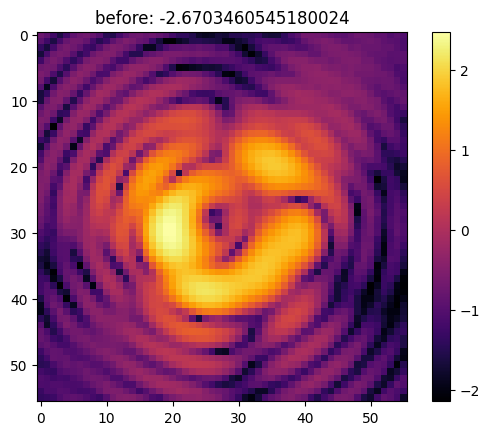

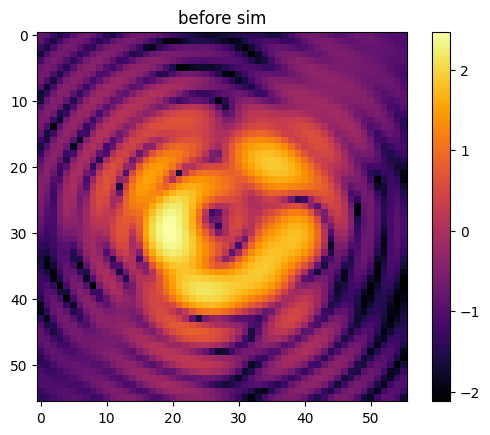

C:\Users\alexe\AppData\Local\Temp\ipykernel_17344\3626112359.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.imshow(np.array(cam_img1) - np.array(img1.cpu()), cmap='inferno')


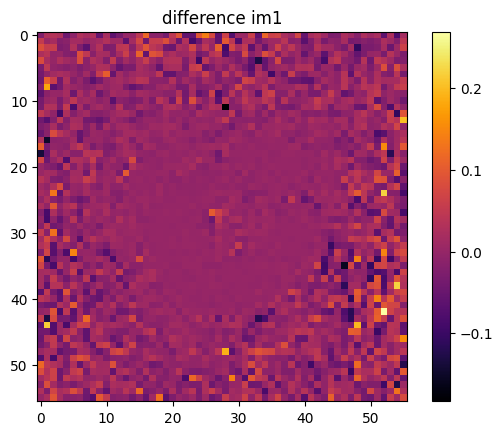

C:\Users\alexe\AppData\Local\Temp\ipykernel_17344\3626112359.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.imshow(np.array(cam_img2) - np.array(img2.cpu()), cmap='inferno')


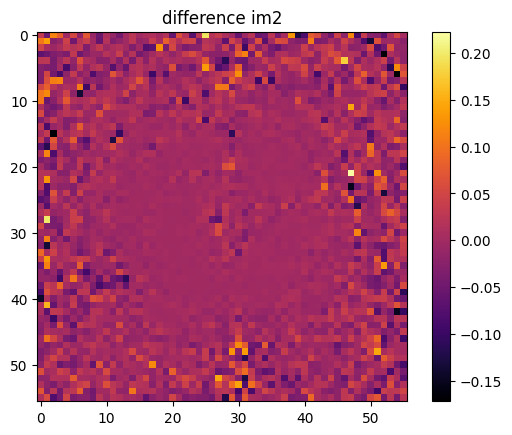

dm_proper: [-5.41138636e-08 -1.00054793e-08  2.66437086e-08 -1.68962143e-08
 -1.33538777e-08 -1.22038907e-08 -1.40982481e-08 -4.75145942e-09
 -2.45478101e-08 -1.14370049e-08  8.16036245e-09  2.82150226e-08
  1.55929111e-08 -3.74324890e-10  1.96840970e-08 -2.58776523e-08
 -1.70070252e-08  2.05174733e-08 -3.46561435e-09  5.42653489e-10
  8.06116163e-09 -2.41704130e-08  9.04007473e-09 -9.26056507e-09
 -3.14953252e-08]
y prediction: [tensor(5.9277e-08), tensor(1.5526e-08), tensor(-3.2841e-08), tensor(1.7080e-08), tensor(8.0494e-09), tensor(3.0985e-09), tensor(1.4686e-08), tensor(-2.5423e-09), tensor(1.3012e-08), tensor(9.5263e-09), tensor(-2.4393e-09), tensor(-1.0681e-08), tensor(-1.0550e-08), tensor(-4.0003e-09), tensor(-6.4586e-09), tensor(1.0602e-08), tensor(1.3840e-08), tensor(-1.8728e-08), tensor(-2.4697e-11), tensor(-9.0999e-09), tensor(1.2161e-09), tensor(1.4386e-08), tensor(-7.8227e-09), tensor(3.7978e-09), tensor(2.3675e-08)]


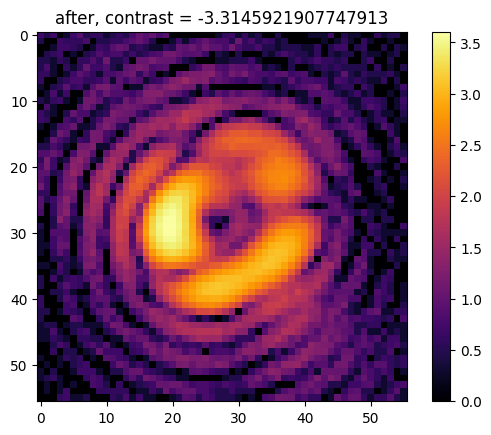

In [19]:
e.deformable_mirror.flatten()
e.set_dm(dm_proper)


original_setting = e.deformable_mirror.actuators.copy()
cam_img1 = torch.asarray(np.log10(1e-15 * e.get_camera_image(delta_t=1e15) + 1), dtype=torch.float)
cam_img1 = (cam_img1 - X_mean) / X_std
e.deformable_mirror.actuators += nudge
cam_img2 = torch.asarray(np.log10(1e-15 * e.get_camera_image(delta_t=1e15) + 1), dtype=torch.float)
cam_img2 = (cam_img2 - X_mean) / X_std
e.deformable_mirror.actuators = original_setting

plt.imshow(img1.cpu(), cmap='inferno')
plt.colorbar()
plt.title(f'before: {np.log10(e.get_contrast())}')
plt.show()

plt.imshow(cam_img1, cmap='inferno')
plt.colorbar()
plt.title('before sim')
plt.show()

plt.imshow(np.array(cam_img1) - np.array(img1.cpu()), cmap='inferno')
plt.colorbar()
plt.title('difference im1')
plt.show()

plt.imshow(np.array(cam_img2) - np.array(img2.cpu()), cmap='inferno')
plt.colorbar()
plt.title('difference im2')
plt.show()
print(f"dm_proper: {dm_proper}")
with torch.no_grad():
    y_pred = cpu_model(cam_img1.unsqueeze(0).unsqueeze(0).cpu(), cam_img2.unsqueeze(0).unsqueeze(0).cpu(), torch.zeros(size=(1,1)).cpu())
    y_pred *= y_std_dev 
    y_pred += y_mean 
    y_pred_list = [-a for a in list(y_pred.cpu()[0])]
    print(f'y prediction: {y_pred_list}')


e.set_dm(y_pred_list)

cam_img1 = np.log10(e.get_camera_image(delta_t=1) + 1)

plt.imshow(cam_img1, cmap='inferno')
plt.colorbar()
plt.title(f'after, contrast = {np.log10(e.get_contrast())}')
plt.show()





In [87]:
e.deformable_mirror.flatten()
e.get_contrast(delta_t=1e15)

np.float64(3.8595709441200285e-07)

In [ ]:
# TODO
# Make a plot, x axis is noise, y axis is contrast post-processing base case, vs performance of my models.
# In the absesnce of noise, performance of SHWFS = traditional probe. 
# Make an informal write up with equations describing my steps (data generation, estimates for electric field are / infer the electric field from the probes, train a model to predict electric fields given intensity)
# how to train: N pixel image -> 2N dimensional vector, first N are real values and second are imaginary values.
# break up the electric field into parametrized modes. 
# mirror mode vs electric field mode -> complex exponent of the mirror mode.
# infinitely many solutions